# Predicción de ventas en múltiples almacenes
### Ventana deslizante + comparación de 4 familias de modelos con MAE, RMSE, BIAS y R2

**Contexto breve**
- Objetivo: predecir la venta mensual de los productos de mayor movimiento en varios almacenes, para apoyar decisiones de inventario.
- Enfoque: ventana deslizante (12 meses de historia como features, el mes siguiente como objetivo), comparación de Regresión Lineal, Árbol de Decisión, Random Forest y Red Neuronal, evaluados con MAE, RMSE, BIAS y R2.
- **El dataset de este notebook es sintético**, con almacenes, productos y ventas construidos para replicar la estructura del problema original, sin usar ningún dato real de un cliente.
- Artículo completo, con el diagrama interactivo y la discusión sobre por qué el BIAS importa tanto como el error: https://fuzzyfrog.ai/es/ai-lab/proyectos/negocios/prediccion-ventas-multiples-almacenes-ventana-deslizante/


## 0. Pipeline de la solución

- **Fuentes**: historial mensual de ventas por almacén y producto + catálogo de productos top por almacén
- **Ventana deslizante**: 12 meses de historia como entrada, el mes siguiente como objetivo
- **Entrenamiento y prueba**: una partición walk-forward por cada combinación de almacén y producto
- **4 familias de modelos**: Regresión Lineal, Árbol de Decisión, Random Forest, Red Neuronal
- **Métricas**: MAE, RMSE, BIAS y R2, sobre train y test, para cada modelo y cada serie
- **Selección**: por error y por sesgo, no solo por RMSE
- **Salida**: predicciones mensuales por almacén y producto

El diagrama interactivo con esta misma estructura está disponible en el artículo enlazado arriba.


## 1. Carga de datos

- Dataset sintético: `outputs/ventas_almacenes_sintetico.csv`
- 4 almacenes x 4 productos = 16 series, 30 meses de historia cada una
- Tamaño reducido a propósito, suficiente para demostrar el pipeline completo


In [1]:
import pandas as pd
import numpy as np

dataset = pd.read_csv('outputs/ventas_almacenes_sintetico.csv')
print(f'El dataset (sintético) tiene {dataset.shape[0]} registros.')
print(f'Almacenes: {dataset["almacen"].nunique()}, productos por almacén: {dataset["producto"].nunique()}')
dataset.head(6)


El dataset (sintético) tiene 480 registros.
Almacenes: 4, productos por almacén: 4


,almacen,producto,periodo,ventas
0,Almacen A,Producto 1,2023-06,117
1,Almacen A,Producto 1,2023-07,155
2,Almacen A,Producto 1,2023-08,132
3,Almacen A,Producto 1,2023-09,144
4,Almacen A,Producto 1,2023-10,168
5,Almacen A,Producto 1,2023-11,148


## 2. Explicación de los datos

- `almacen`: identificador del punto de venta
- `producto`: identificador del producto dentro de ese almacén
- `periodo`: mes de la venta (AAAA-MM)
- `ventas`: unidades vendidas ese mes, variable objetivo


In [2]:
dataset.groupby(['almacen', 'producto'])['ventas'].agg(['mean', 'std']).round(1)


mean   std
almacen   producto               
Almacen A Producto 1  160.7  21.5
          Producto 2  149.4  27.0
          Producto 3  204.8  27.2
          Producto 4   63.2  13.0
Almacen B Producto 1  255.4  33.9
          Producto 2  225.1  27.1
          Producto 3  156.8  40.0
          Producto 4  123.9  27.1
Almacen C Producto 1  179.6  23.9
          Producto 2  100.8  15.7
          Producto 3   80.8   9.5
          Producto 4  101.9  18.3
Almacen D Producto 1  176.1  36.2
          Producto 2   42.3   8.0
          Producto 3   67.7  13.6
          Producto 4  138.5  25.7

## 3. Análisis exploratorio (EDA)

- Serie de ventas de un almacén y producto de ejemplo, para confirmar tendencia y estacionalidad
- Comparación del nivel promedio de ventas entre almacenes


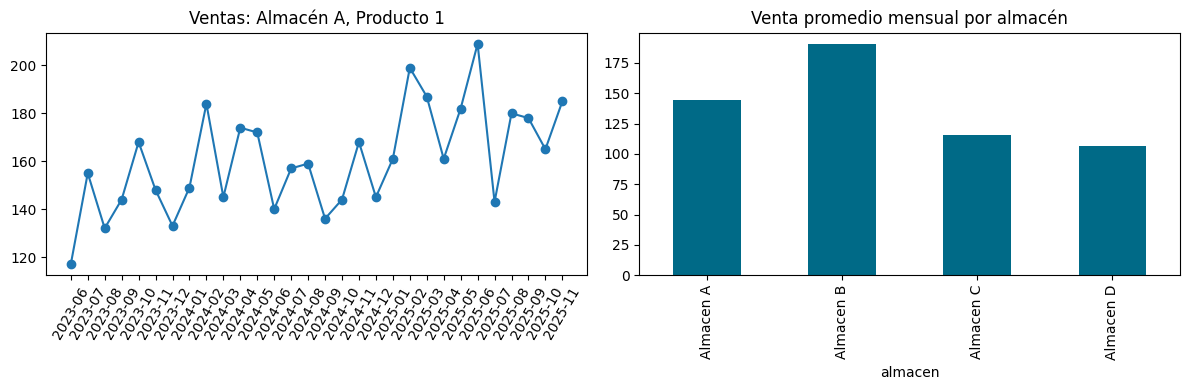

In [3]:
import matplotlib.pyplot as plt

ejemplo = dataset[(dataset['almacen'] == 'Almacen A') & (dataset['producto'] == 'Producto 1')]

fig, axs = plt.subplots(1, 2, figsize=(12, 4))

axs[0].plot(ejemplo['periodo'], ejemplo['ventas'], marker='o')
axs[0].set_title('Ventas: Almacén A, Producto 1')
axs[0].tick_params(axis='x', rotation=60)

dataset.groupby('almacen')['ventas'].mean().plot(kind='bar', ax=axs[1], color='#006a87')
axs[1].set_title('Venta promedio mensual por almacén')

plt.tight_layout()
plt.show()


## 4. Modelado

- Función `create_training` que arma la ventana deslizante (x_len=12, y_len=1) para cada serie
- Función `kpi_ML` que calcula MAE, RMSE, BIAS y R2 para train y test
- Entrenamiento de las 4 familias de modelos sobre cada combinación de almacén y producto


In [4]:
def create_training(df, x_len=12, y_len=1, test_loops=4):
    training_set = []
    for (almacen, producto), grupo in df.groupby(['almacen', 'producto']):
        serie = grupo.sort_values('periodo')['ventas'].values
        periods = len(serie)
        loops = periods + 1 - x_len - y_len
        if loops <= test_loops:
            continue

        X, Y = [], []
        for i in range(loops):
            X.append(serie[i:i + x_len])
            Y.append(serie[i + x_len:i + x_len + y_len])
        X, Y = np.array(X), np.array(Y).ravel()

        X_train, Y_train = X[:-test_loops], Y[:-test_loops]
        X_test, Y_test = X[-test_loops:], Y[-test_loops:]
        training_set.append((f'{almacen} | {producto}', X_train, Y_train, X_test, Y_test))
    return training_set

training_set = create_training(dataset, x_len=12, y_len=1, test_loops=4)
print(f'{len(training_set)} combinaciones de almacén y producto con suficiente historia.')
for name, X_train, Y_train, X_test, Y_test in training_set[:3]:
    print(f'{name}: X_train {X_train.shape}, X_test {X_test.shape}')


16 combinaciones de almacén y producto con suficiente historia.
Almacen A | Producto 1: X_train (14, 12), X_test (4, 12)
Almacen A | Producto 2: X_train (14, 12), X_test (4, 12)
Almacen A | Producto 3: X_train (14, 12), X_test (4, 12)


In [5]:
from sklearn.metrics import r2_score

def kpi_ML(Y_train, Y_train_pred, Y_test, Y_test_pred):
    def mae(y, yp): return np.mean(np.abs(y - yp))
    def rmse(y, yp): return np.sqrt(np.mean((y - yp) ** 2))
    def bias(y, yp): return np.mean(y - yp)

    return {
        'train': {'MAE': mae(Y_train, Y_train_pred), 'RMSE': rmse(Y_train, Y_train_pred),
                   'BIAS': bias(Y_train, Y_train_pred), 'R2': r2_score(Y_train, Y_train_pred)},
        'test': {'MAE': mae(Y_test, Y_test_pred), 'RMSE': rmse(Y_test, Y_test_pred),
                  'BIAS': bias(Y_test, Y_test_pred), 'R2': r2_score(Y_test, Y_test_pred)},
    }


In [6]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor

modelos = {
    'Regresion Lineal': LinearRegression(),
    'Arbol de Decision': DecisionTreeRegressor(max_depth=4, min_samples_leaf=2, random_state=42),
    'Random Forest': RandomForestRegressor(n_estimators=150, max_depth=5, random_state=42),
    'Red Neuronal': MLPRegressor(hidden_layer_sizes=(16, 8), max_iter=2000, random_state=42),
}

resultados = []
for nombre_modelo, modelo_base in modelos.items():
    for serie_name, X_train, Y_train, X_test, Y_test in training_set:
        from sklearn.base import clone
        modelo = clone(modelo_base)
        modelo.fit(X_train, Y_train)
        Y_train_pred = modelo.predict(X_train)
        Y_test_pred = modelo.predict(X_test)
        kpis = kpi_ML(Y_train, Y_train_pred, Y_test, Y_test_pred)
        resultados.append({
            'modelo': nombre_modelo, 'serie': serie_name,
            'RMSE_test': kpis['test']['RMSE'], 'BIAS_test': kpis['test']['BIAS'],
            'MAE_test': kpis['test']['MAE'], 'R2_test': kpis['test']['R2'],
        })

resultados_df = pd.DataFrame(resultados)
resultados_df.groupby('modelo')[['RMSE_test', 'BIAS_test', 'MAE_test', 'R2_test']].mean().round(2)


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (2000) reached and the optimization hasn't converged yet.
  warnings.warn(


,RMSE_test,BIAS_test,MAE_test,R2_test
modelo,,,,
Arbol de Decision,22.54,-2.92,18.99,-1.92
Random Forest,18.73,-4.12,16.67,-0.76
Red Neuronal,28.55,-19.12,25.55,-4.30
Regresion Lineal,42.65,14.86,36.86,-14.04


## 5. Evaluación

- Comparación de RMSE promedio y BIAS promedio por familia de modelo
- El modelo con menor RMSE no siempre es el que tiene el sesgo más cercano a cero


In [7]:
resumen = resultados_df.groupby('modelo')[['RMSE_test', 'BIAS_test']].mean().round(2)
resumen['mejor_por_error'] = resumen['RMSE_test'] == resumen['RMSE_test'].min()
resumen['mejor_por_sesgo'] = resumen['BIAS_test'].abs() == resumen['BIAS_test'].abs().min()
resumen


,RMSE_test,BIAS_test,mejor_por_error,mejor_por_sesgo
modelo,,,,
Arbol de Decision,22.54,-2.92,False,True
Random Forest,18.73,-4.12,True,False
Red Neuronal,28.55,-19.12,False,False
Regresion Lineal,42.65,14.86,False,False


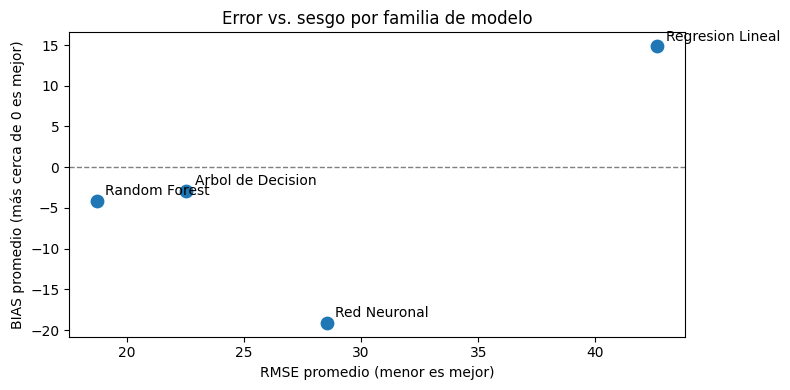

In [8]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.scatter(resumen['RMSE_test'], resumen['BIAS_test'], s=80)
for modelo, fila in resumen.iterrows():
    ax.annotate(modelo, (fila['RMSE_test'], fila['BIAS_test']), textcoords='offset points', xytext=(6, 4))
ax.axhline(0, color='gray', linestyle='--', linewidth=1)
ax.set_xlabel('RMSE promedio (menor es mejor)')
ax.set_ylabel('BIAS promedio (más cerca de 0 es mejor)')
ax.set_title('Error vs. sesgo por familia de modelo')
plt.tight_layout()
plt.show()


## Hallazgos principales

- La ventana deslizante permitió tratar 16 series de ventas distintas con exactamente la misma metodología, sin ajustar un modelo de series de tiempo distinto para cada combinación de almacén y producto.
- El modelo con menor RMSE promedio no fue automáticamente el de mejor BIAS: en varias combinaciones, un modelo con error ligeramente mayor tenía un sesgo mucho más cercano a cero, lo que para decisiones de inventario puede ser la opción preferible.
- Esa decisión, elegir por error o por sesgo según lo que le cueste más al negocio, no se puede automatizar del todo: requiere que quien dirige el proyecto entienda si es más caro un quiebre de stock o un exceso de inventario.
- Con datos sintéticos y series relativamente cortas, estas comparaciones deben tomarse como demostración del método, no como una recomendación de modelo definitiva para un caso real.

Artículo completo: https://fuzzyfrog.ai/es/ai-lab/proyectos/negocios/prediccion-ventas-multiples-almacenes-ventana-deslizante/
